In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
df = pd.read_csv("cleaned_cafe_sales.csv")
df.head()

,transaction_id,item,quantity,price_per_unit,total_spent,payment_method,location,transaction_date,month,day_name
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,08-09-2023,9.0,Friday
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-Store,16-05-2023,5.0,Tuesday
2,TXN_4271903,Cookie,4,1.0,4.0,Credit Card,In-Store,19-07-2023,7.0,Wednesday
3,TXN_7034554,Salad,2,5.0,10.0,Unknown,Unknown,27-04-2023,4.0,Thursday
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-Store,11-06-2023,6.0,Sunday


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   transaction_id    10000 non-null  str    
 1   item              10000 non-null  str    
 2   quantity          10000 non-null  int64  
 3   price_per_unit    10000 non-null  float64
 4   total_spent       10000 non-null  float64
 5   payment_method    10000 non-null  str    
 6   location          10000 non-null  str    
 7   transaction_date  9540 non-null   str    
 8   month             9540 non-null   float64
 9   day_name          9540 non-null   str    
dtypes: float64(3), int64(1), str(6)
memory usage: 781.4 KB


In [9]:
df.describe()

,quantity,price_per_unit,total_spent,month
count,10000.000000,10000.00000,10000.000000,9540.000000
mean,3.027100,2.95265,8.948150,6.524004
std,1.384614,1.24396,5.831191,3.449446
min,1.000000,1.00000,1.000000,1.000000
25%,2.000000,2.00000,4.000000,4.000000
50%,3.000000,3.00000,8.000000,7.000000
75%,4.000000,4.00000,12.000000,10.000000
max,5.000000,5.00000,25.000000,12.000000


In [10]:
df['item'].value_counts()

item
Juice       1171
Coffee      1165
Salad       1148
Cake        1139
Sandwich    1131
Smoothie    1096
Cookie      1092
Tea         1089
Unknown      969
Name: count, dtype: int64

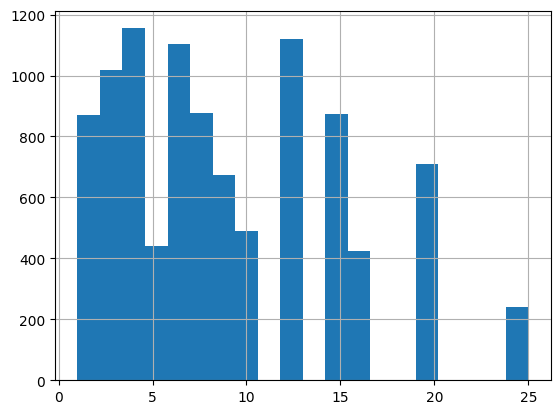

In [11]:
df['total_spent'].hist(bins=20)
plt.show()

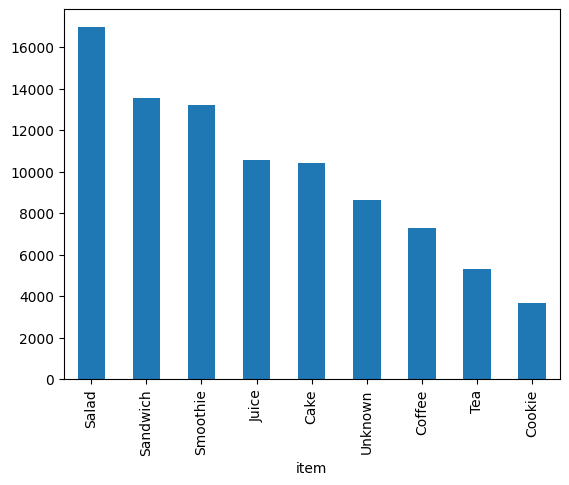

In [12]:
df.groupby('item')['total_spent'].sum().sort_values(ascending=False).plot(kind='bar')
plt.show()

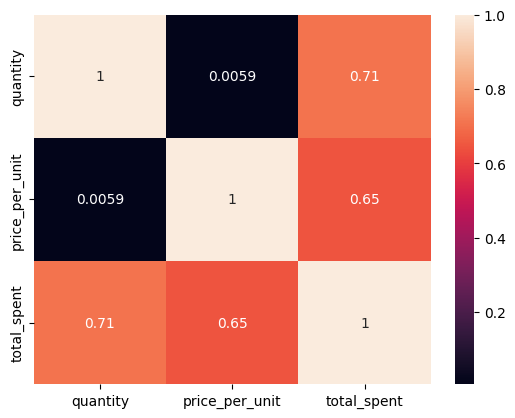

In [13]:
sns.heatmap(
    df[['quantity','price_per_unit','total_spent']].corr(),
    annot=True
)
plt.show()

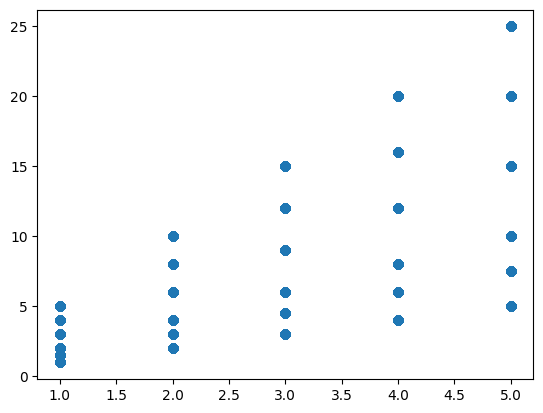

In [14]:
plt.scatter(df['quantity'], df['total_spent'])
plt.show()

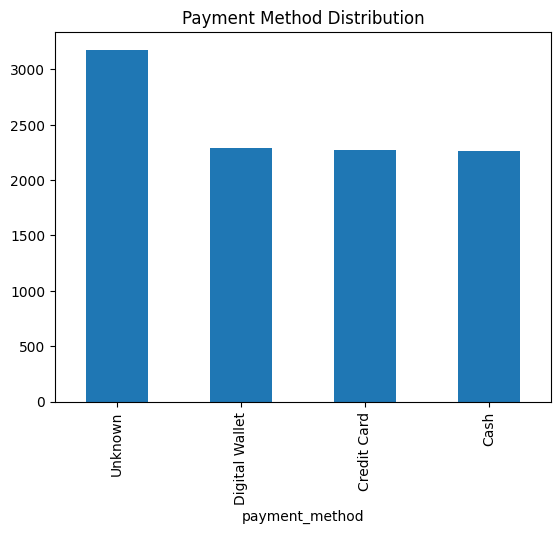

In [15]:
df['payment_method'].value_counts().plot(kind='bar')
plt.title("Payment Method Distribution")
plt.show()

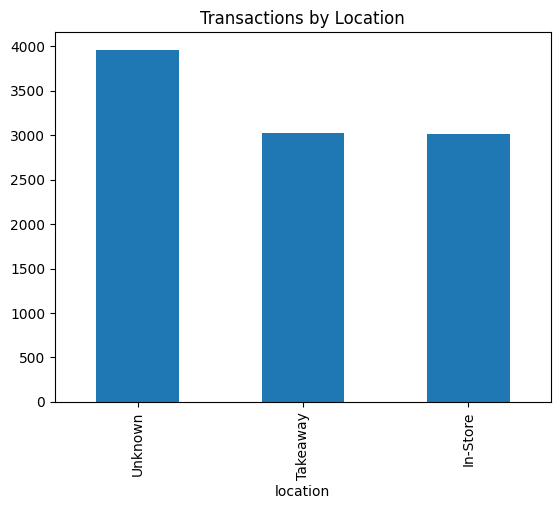

In [16]:
df['location'].value_counts().plot(kind='bar')
plt.title("Transactions by Location")
plt.show()

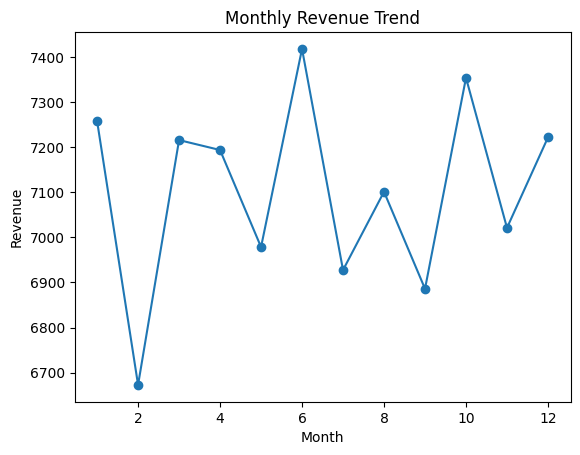

In [17]:
df.groupby('month')['total_spent'].sum().plot(kind='line', marker='o')
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.show()

In [18]:
import sqlite3

conn = sqlite3.connect(':memory:')
df.to_sql('cafe_sales', conn, index=False, if_exists='replace')

10000

In [19]:
query = """
SELECT item,
SUM(total_spent) AS revenue
FROM cafe_sales
GROUP BY item
ORDER BY revenue DESC
"""

pd.read_sql_query(query, conn)

,item,revenue
0,Salad,16959.0
1,Sandwich,13538.0
2,Smoothie,13218.0
3,Juice,10542.0
4,Cake,10401.0
5,Unknown,8615.0
6,Coffee,7261.0
7,Tea,5296.5
8,Cookie,3651.0


In [20]:
query = """
SELECT item,
SUM(total_spent) AS revenue
FROM cafe_sales
GROUP BY item
ORDER BY revenue DESC
"""

pd.read_sql_query(query, conn)

,item,revenue
0,Salad,16959.0
1,Sandwich,13538.0
2,Smoothie,13218.0
3,Juice,10542.0
4,Cake,10401.0
5,Unknown,8615.0
6,Coffee,7261.0
7,Tea,5296.5
8,Cookie,3651.0


In [21]:
query = """
SELECT payment_method,
COUNT(*) AS transactions
FROM cafe_sales
GROUP BY payment_method
"""

pd.read_sql_query(query, conn)

,payment_method,transactions
0,Cash,2258
1,Credit Card,2273
2,Digital Wallet,2291
3,Unknown,3178
